# Enunciado de la Entrega de Aprendizaje Automático – Grado Física

**Fecha de entrega:** 8 de enero a las 23.59 (un día antes del examen del 9 de enero)

**Objetivo:**
En esta actividad (¡aprovechando el espíritu navideño para aprender! 🎄), hay que desarrollar y comparar modelos de *Machine Learning* tanto tradicionales como de *Deep Learning* empleando un conjunto de datos público. Se busca un enfoque práctico: experimentar con varios modelos, optimizar sus parámetros y extraer conclusiones sobre el rendimiento de cada enfoque. (Considerad esta entrega como un regalo académico anticipado 🎁: la oportunidad de demostrar todo lo aprendido en la asignatura).

## Instrucciones:

**1. Selección del dataset:**
Escoge **uno** de los conjuntos de datos públicos sugeridos (ver lista más abajo). Puede ser tabular (datos estructurados) o de imágenes, según tu preferencia.

**2. Preparación de los datos:**
Realiza una limpieza básica y preparación del dataset antes de entrenar. No es necesario invertir mucho tiempo en ingeniería de características; simplemente asegúrate de que los datos estén en un formato adecuado (ejemplo: manejo de valores ausentes, conversión de categorías a numérico si aplica, normalización si es pertinente). La idea es dejar el conjunto de datos “listo para usar” de forma sencilla, sin profundizar demasiado en esta fase.

**3. Entrenamiento de modelos:**
* Entrena **al menos un modelo de *Machine Learning* tradicional**, por ejemplo un *k*-NN, SVM o Random Forest, utilizando el dataset elegido. Prueba distintos hiperparámetros en este modelo clásico.
* Entrena **también un modelo de red neuronal simple** (una red *feed-forward* o una CNN si son imágenes) utilizando Keras (TensorFlow) con el mismo conjunto de datos. También aquí, experimenta con la arquitectura o parámetros (número de capas, neuronas, épocas, etc.) dentro de lo razonable.
* *Nota:* Si lo consideras adecuado, puedes **probar más modelos o enfoques adicionales** (por ejemplo, otro algoritmo tradicional, o una arquitectura de red diferente). Cualquier método novedoso o extra que pruebes será bien recibido siempre que esté justificado en tu informe. ¡Si tienes una idea creativa, adelante!

**4. Evaluación y comparación:**
Utiliza métricas adecuadas según el tipo de problema para evaluar los modelos. Por ejemplo, precisión, recall, F1 si es clasificación; o RMSE, MAE si es regresión. Compara el rendimiento de los modelos tradicionales vs. la red neuronal. ¿Cuál funciona mejor en tu caso y por qué? ¿Hay mucha diferencia entre ellos? Comenta posibles razones (tamaño de datos, hiperparámetros, capacidad del modelo, etc.). Puedes apoyar tus conclusiones con tablas o gráficas comparativas de las métricas.

**5. Informe final:**
Elabora un informe breve (puede ser en Jupyter Notebook con Markdown o un documento aparte) donde expliques:

* **Proceso seguido:** cómo preparaste los datos, qué modelos entrenaste y cómo los configuraste.
* **Resultados:** compara las métricas obtenidas y discute cuál modelo rindió mejor. Incluye cualquier observación interesante (por ejemplo, “el modelo X sobreajustó”, “la red neuronal mejoró tras normalizar los datos”, etc.).
* **Conclusiones y mejoras:** propone posibles mejoras o siguientes pasos. Por ejemplo, ¿qué harías para mejorar el modelo si tuvieras más tiempo? ¿Añadir más datos, más features, ajustar algún parámetro? Además, reflexiona sobre **aplicaciones prácticas**: ¿a quién podría interesarle este modelo ya entrenado? ¿En qué contexto real sería útil la solución?
* Trata de darle un cierre reflexivo. (¡Piensa en esto como las conclusiones finales del año, con un guiño a las fiestas! 🎅 ✨)

___

## Introducción y carga de datos

En este trabajo, haremos una comparación del comportamiento del Machine Learning tradicional con el Deep Learning en la predicción de imágenes, donde principalmente estudiaremos la relación entre la efectividad y el coste computacional. 


Este análisis se realizará utilizando el dataset MNIST, integrada en la API de Keras. La naturaleza de estas imágenes, dígitos manuscritos en escala de grises de 28x28 píxeles, tiene el equilibrio perfecto de complejidad, pues son lo suficientemente ligeras para un entrenamiento rápido, pero conservan la estructura espacial necesaria para poner a prueba las capacidades de extracción de características del Deep Learning frente al Machine Learning tradicional.

c:\Users\claud\miniconda3\envs\entorno_NASA\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


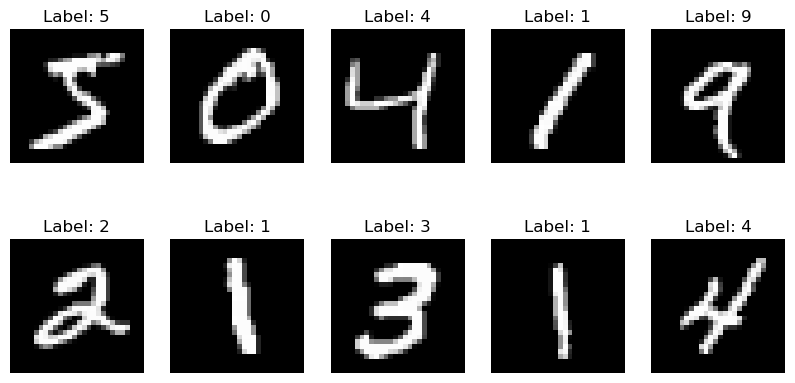

Forma de los datos de entrenamiento: (60000, 28, 28)
Forma de los datos de test: (10000, 28, 28)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV



# 1. Cargar MNIST (ya viene dividido en train y test)
(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.mnist.load_data()

# Visualizar algunas muestras
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train_raw[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

print(f"Forma de los datos de entrenamiento: {X_train_raw.shape}")
print(f"Forma de los datos de test: {X_test_raw.shape}")

    Esto significa que tenemos 60000 imágenes de entrenamiento y 10000 de prueba, todas de $28 \times 28$ píxeles.

Al tratarse de imágenes, nuestros datos de entrada que nos proporcionanson los propios valores de los niveles de intensidad de luz de cada píxel. Como están compuestas por una escala de grises y el nivel de profundidad para esta suele ser de 8 bits, es decir, los niveles que pueden alcanzar será entre 0 y 255. Este rango lo normalizaremos entre 0 y 1 para que la red aprenda mejor y más rápido.

## Limpieza y tratamiento de datos

Primero, procedemos a una parte de limpieza de datos, asegurándonos de que los datos que contienen las variables de entrada son todos numéricos.

In [2]:
print("--- Auditoría de Tipos de Datos (Naturaleza) ---")
# Usamos las variables _raw porque acabamos de cargar los datos
print(f"X_train (Imágenes): {X_train_raw.dtype}")
print(f"y_train (Etiquetas): {y_train.dtype}")
print(f"X_test  (Imágenes): {X_test_raw.dtype}")
print(f"y_test  (Etiquetas): {y_test.dtype}")

--- Auditoría de Tipos de Datos (Naturaleza) ---
X_train (Imágenes): uint8
y_train (Etiquetas): uint8
X_test  (Imágenes): uint8
y_test  (Etiquetas): uint8


Efectivamente, con uint 8, nuestros datos son todo numéricos y enteros, reafirmando además la suposición de la profundidad de 8 bits y de los niveles establecidos. 

Posteriormente, realizaremos una búsqueda de NaNs. Aunque en MNIST es muy raro que hayan, haremos la prueba igualmente, pues además el coste de cómputo es muy pequeño.

In [3]:
# --- BÚSQUEDA DE VALORES NULOS (NaNs) ---
# np.isnan(datos) devuelve una matriz de True/False
# .any() devuelve True si encuentra al menos un "True" en la matriz
hay_nans_train = np.isnan(X_train_raw).any()
hay_nans_test = np.isnan(X_test_raw).any()

print(f"\n¿Hay NaNs en train?: {hay_nans_train}")
print(f"¿Hay NaNs en test?: {hay_nans_test}")


¿Hay NaNs en train?: False
¿Hay NaNs en test?: False


Ahora sí, con la seguridad de que no hay nulos, pasamos a la normalización de los datos. Pero además en esta celda, haremos la conversión de la forma o "reshape" para que los datos sean compatibles con cada modelo. Para Machine Learning "tradicional", aplanaremos los datos de las imagenes (flatten), en nuestro caso de 2D a 1D, convirtiéndolas en vectores de características unidimensionales y perdiendo la estructura espacial, lo necesario para estos casos.
Transformación: $(28, 28) \rightarrow (784,)

Sin embargo, para Deep Learning, mantendremos la estructura 2D de la imagen y añadimos una dimensión extra para el canal de color (escala de grises), lo que permite a la red detectar patrones espaciales.
Transformación: $(28, 28) \rightarrow (28, 28, 1)$

In [4]:
# Normalización (para ambos): Convertir de 0-255 a 0-1
X_train_norm = X_train_raw.astype("float32") / 255.0
X_test_norm = X_test_raw.astype("float32") / 255.0

# --- PREPARACIÓN PARA ML TRADICIONAL ---
# Aplanamos: (60000, 28, 28) -> (60000, 784)
X_train_flat = X_train_norm.reshape((X_train_norm.shape[0], -1))  # mantenemos el número de muestras, aplanamos el resto teniendo en cuenta 28x28=784
X_test_flat = X_test_norm.reshape((X_test_norm.shape[0], -1))  

# --- PREPARACIÓN PARA DEEP LEARNING (Reshape para CNN) ---
# Añadimos canal de color: (60000, 28, 28, 1)
X_train_cnn = np.expand_dims(X_train_norm, -1)  # input la matriz original pero el -1 nos añade un eje al final
X_test_cnn = np.expand_dims(X_test_norm, -1)

print("Datos listos. Flat shape:", X_train_flat.shape, "| CNN shape:", X_train_cnn.shape)

Datos listos. Flat shape: (60000, 784) | CNN shape: (60000, 28, 28, 1)


Siguiendo con la limpieza, ahora comprobaremos los duplicados con los vectores conseguidos para el modelo de ML. Aunque MNIST sea un dataset limpio en general, aún así lo comprobamos. Analizándolo por vectores nos permite obtener el mismo rsultado que con más dimensiones (es decir, la existencia de duplicados) pero con un coste mucho menor.

In [5]:
# 1. Obtenemos los valores únicos y sus conteos (frecuencias)
# axis=0 asegura que comparamos filas (imágenes) completas
vals_unicos, conteos = np.unique(X_train_flat, axis=0, return_counts=True)

# 2. Filtramos aquellos que aparecen más de 1 vez
duplicados = vals_unicos[conteos > 1]
cantidad_duplicados = len(duplicados)

print(f"¿Existen duplicados? {'Sí' if cantidad_duplicados > 0 else 'No'}")
print(f"Número de patrones de imagen que se repiten: {cantidad_duplicados}")


¿Existen duplicados? No
Número de patrones de imagen que se repiten: 0


Seguros de que la posible "suciedad" es inexistente en nuestros datos, pasamos al entrenamiento de los modelos.

## Entrenamiento y análisis de resultados

Para la evaluación de los modelos se han utilizado distintas métricas en función de la naturaleza y las herramientas de entrenamiento de cada uno. En el caso del Random Forest, se ha analizado el rendimiento mediante precision, recall y f1-score por clase, además de la accuracy global. Estas métricas ofrecen una visión más completa del comportamiento del clasificador, permitiendo evaluar no solo el porcentaje total de aciertos, sino también el equilibrio entre falsos positivos y falsos negativos para cada clase individual. Dado que el problema es multiclase y las clases están relativamente balanceadas, el uso de promedios macro y ponderados resulta especialmente útil para detectar posibles sesgos del modelo hacia determinadas categorías.

Por el contrario, en el entrenamiento de la CNN se han monitorizado principalmente la accuracy y la función de pérdida (loss) tanto en el conjunto de entrenamiento como en el de validación a lo largo de las épocas. Esto se debe a que, durante el proceso de entrenamiento de redes neuronales profundas, estas métricas son las más informativas para analizar la convergencia del modelo, la estabilidad del aprendizaje y la posible presencia de sobreajuste. Además, el cálculo de métricas como precision o recall por clase no se realiza de forma automática durante el entrenamiento y suele reservarse para una evaluación posterior sobre el conjunto de test. Aun así, los valores elevados y estables de accuracy de validación, junto con la disminución progresiva de la loss, indican un buen rendimiento y una adecuada capacidad de generalización de la CNN.

### Machine Learning: Random Forest

En cuanto a la parte del Machine Learning, como nuestro dataset es etiquetado, emplearemos modelos supervisados de clasificación. Por eficiencia elegimos Random Forest, pues KNN sería demasaido lento y pesado al mediar las distancias entre todos los píxeles de las 60000 imagenes y en SVM tendríamos que emplear un Kernel (no lineal) volviéndose pesado al tener que hacer cálculos matemáticos complejos con muchos vectores de soporte. Por ello, RF simplemente es un proceso de lógica, ganando el equilibrio entre velocidad/potencia.

In [6]:
# 1. Definimos el modelo correcto (Clasificador)
rf_model = RandomForestClassifier(random_state=42)

# 2. Definimos la rejilla de parámetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# 3. Configuramos el Grid Search
# Usamos 'f1_macro' porque tenemos 10 clases balanceadas
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='f1_macro', 
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("Buscando los mejores hiperparámetros... ")
# Recuerda usar los datos planos (X_train_flat)
grid_search.fit(X_train_flat, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")

# Predicción
y_pred_rf = grid_search.predict(X_test_flat)

print("Reporte RF:")
print(classification_report(y_test, y_pred_rf))

Buscando los mejores hiperparámetros... 
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Reporte RF:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.98      0.97      0.98       982
           5       0.97      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



Observamos que en los hiperparámetros max_depth y min_samples_split, obtenemos como mejores resultados los valores por defecto de la librería, por tanto su variación no mejora el modelo. Por ello, mantendremos estos dos parámetros en sus valores por defecto y nos centraremos en el análisis en la variación de n_estimators, pudiendo además enfocarnos mejor en el balance de resultados y tiempo de cálculo.

In [7]:
import time
import pandas as pd
from sklearn.metrics import accuracy_score

# Definimos las opciones a probar
cantidades_arboles = [25, 50, 100, 200, 250]
resultados = []

print("Comenzando análisis... ")

for n in cantidades_arboles:
    # 1. Configurar el modelo con n árboles
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    
    # 2. Encender el cronómetro 
    inicio = time.time()
    
    # 3. Entrenar
    rf.fit(X_train_flat, y_train)
    
    # 4. Parar el cronómetro
    fin = time.time()
    tiempo_transcurrido = fin - inicio
    
    # 5. Evaluar
    y_pred = rf.predict(X_test_flat)
    exactitud = accuracy_score(y_test, y_pred)
    
    # 6. Guardar los datos
    resultados.append({
        "N_Arboles": n,
        "Tiempo (segundos)": round(tiempo_transcurrido, 4),
        "Accuracy": round(exactitud, 4)
    })
    
    print(f"Modelo con {n} árboles terminado.")

# Crear una tabla bonita con Pandas
df_comparativa = pd.DataFrame(resultados)
print("\n--- TABLA COMPARATIVA ---")
print(df_comparativa)

Comenzando análisis... 
Modelo con 25 árboles terminado.
Modelo con 50 árboles terminado.
Modelo con 100 árboles terminado.
Modelo con 200 árboles terminado.
Modelo con 250 árboles terminado.

--- TABLA COMPARATIVA ---
   N_Arboles  Tiempo (segundos)  Accuracy
0         25             6.8012    0.9627
1         50            13.7259    0.9668
2        100            37.3646    0.9704
3        200            61.8097    0.9707
4        250            80.5843    0.9711


Observamos que encontramos el límite de la efectividad del modelo en relación a su tiempo de ejecución, donde entre el primer y el último análisis, con 25 y 250 árboles respectivamente, hay una diferencia de tiempo de aproximadamente 67 segundos para una diferencia de accuracy menor de 0.01. Realizamos un gráfico para visualizar estas diferencias y decidir el mejor modelo.

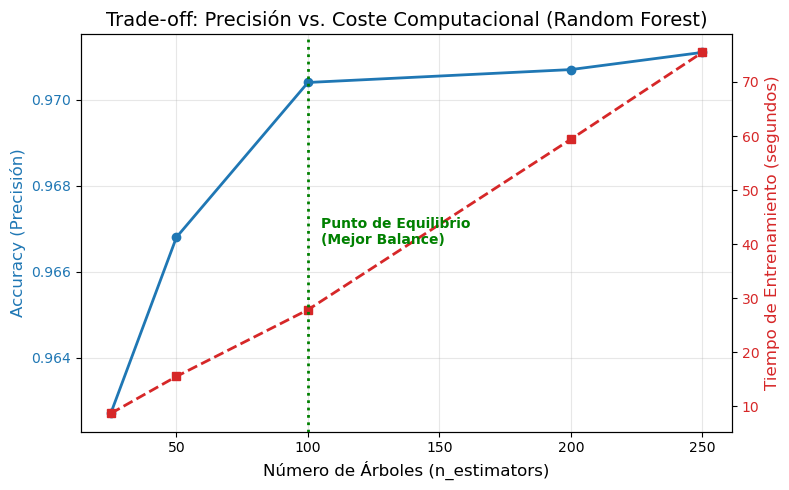

In [8]:
import matplotlib.pyplot as plt

# 1. Cargamos los datos manualmente para el gráfico
n_arboles = [25, 50, 100, 200, 250]
tiempos = [8.69, 15.54, 27.87, 59.41, 75.47]
accuracies = [0.9627, 0.9668, 0.9704, 0.9707, 0.9711]

# 2. Configurar el gráfico
fig, ax1 = plt.subplots(figsize=(8, 5))

# --- EJE 1: ACCURACY (AZUL) ---
color = 'tab:blue'
ax1.set_xlabel('Número de Árboles (n_estimators)', fontsize=12)
ax1.set_ylabel('Accuracy (Precisión)', color=color, fontsize=12)
ax1.plot(n_arboles, accuracies, color=color, marker='o', linewidth=2, label='Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# --- EJE 2: TIEMPO (ROJO) ---
# Instanciamos un segundo eje que comparte el mismo eje X
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Tiempo de Entrenamiento (segundos)', color=color, fontsize=12)
ax2.plot(n_arboles, tiempos, color=color, marker='s', linestyle='--', linewidth=2, label='Tiempo')
ax2.tick_params(axis='y', labelcolor=color)

# 3. Señalar el punto óptimo (100 árboles)
plt.axvline(x=100, color='green', linestyle=':', linewidth=2)
plt.text(105, 40, 'Punto de Equilibrio\n(Mejor Balance)', color='green', fontweight='bold')

plt.title('Trade-off: Precisión vs. Coste Computacional (Random Forest)', fontsize=14)
fig.tight_layout()  # Ajustar márgenes
plt.show()

Aunque esto es aprendizaje supervisado, emplearemos la intuición visual o concepto de la Técnica del Codo (Elbow Method). 
Vemos que la línea azul sube rápido y luego se "dobla" y se aplana. Ese punto de inflexión (donde marcamos la línea verde en 100 árboles) es el codo que buscamos, y es a partir de donde el esfuerzo extra ya no merece la pena.

Obtenemos las métricas para analizar con precisión este modelo óptimo.

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Crear e instanciar modelo
# n_jobs=-1 usa todos los núcleos de tu CPU (¡paralelización!)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Entrenando Random Forest... ")
rf_model.fit(X_train_flat, y_train)

# Predicción
y_pred_rf = rf_model.predict(X_test_flat)

# Evaluación rápida
print("Reporte RF:")
print(classification_report(y_test, y_pred_rf))

Entrenando Random Forest... 
Reporte RF:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



Analizando las métricas, podemos afirmar que este modelo ha logrado una exactitud global del 97%, estableciendo una línea base de rendimiento muy sólida. Al analizarlas por clase, observamos que el 0 y el 1 obtienen resultados casi perfectos (F1-score del 98-99%) gracias a su estructura geométrica distintiva y fácil de aislar a nivel de píxel. Sin embargo, el rendimiento desciende ligeramente en dígitos con estructuras más complejas o intrincadas como el 8 y 9 (Recall $=$ 0.95).Este comportamiento confirma que, aunque el modelo es eficaz, empieza a encontrar dificultades para diferenciar trazos que comparten similitudes espaciales (como las curvas inferiores del 3, 5 y 8), evidenciando las limitaciones de procesar imágenes como vectores planos sin considerar su estructura 2D.

### Deep Learning: CNN

Por otro lado, en el Deep Learning, emplearemos una Red Neuronal Convolucional (CNN) secuencial que prioriza el equilibrio entre capacidad de aprendizaje y eficiencia computacional. Las CNN están diseñadas específicamente para procesar datos con topología de rejilla como una matriz de píxeles (que serían nuestras imagenes),mientras que las RNN están optimizadas para datos secuenciales o temporales (como texto o audio), donde el orden anterior determina el siguiente. Para aplicar una RNN a una imagen, tendríamos que "aplanarla" o leerla píxel a píxel como una secuencia lineal, presentando problemas. En breves palabras, CNN trabaja mejor en el sentido espacial y las RNN en el temporal.

El modelo diseñado lo iniciamos con un bloque convolucional progresivo de dos capas (aumentando de 32 a 64 filtros). Se ha limitado la profundidad a dos niveles debido a la simplicidad de las imagenes (trazos simples en escala de grises), pues una red más profunda añadiría coste computacional innecesario sin mejoras significativas, incluso pudiendo provocar una pérdida excesiva de información espacial sin aportar beneficios en la abstracción de características.

Siguiendo los principios de la arquitectura VGG (una de las arquitecturas de redes neuronales más famosas e influyentes en la historia del Deep Learning), empleamos kernels de $3 \times 3$ con activación ReLU. Esta configuración es estándar en la industria porque permite capturar detalles locales con gran eficiencia de parámetros, a la vez que la no-linealidad que proporciona acelera e incluso hace posible la convergencia del entrenamiento. Esta función de activación es elegida también por su capacidad para mitigar el problema del desvanecimiento del gradiente y su bajo coste computacional frente a funciones clásicas como la Sigmoide o Tanh. 
Tras cada convolución, aplicaremos capas de MaxPooling ($2 \times 2$). Estas reducen la dimensión espacial de los mapas de características a la mitad, eliminando información redundante y dotando al modelo invarianza a la traslación, permitiendo reconocer el dígito independientemente de pequeños desplazamientos en la imagen. Para la etapa final, utilizamos una capa Flatten que transforma la estructura 3D resultante en un vector unidimensional apto para la clasificación. Antes de la predicción, introducimos una capa de Dropout del 50%, una técnica de regularización que apaga aleatoriamente la mitad de las neuronas en cada paso, forzando a la red a aprender patrones robustos y distribuidos y evitando así que el modelo memorice los datos de entrenamiento (overfitting).
La red finaliza con una capa densa de 10 neuronas, correspondientes a las 10 clases posibles (dígitos 0-9). Utilizamos la función de activación Softmax en lugar de ReLU para transformar los valores numéricos finales en una distribución de probabilidad normalizada, permitiendo identificar con claridad la clase ganadora.

En cuanto a la configuración de la compilación, para la función de pérdida empleamos esparse_categorical_crossentropy, ya que estamos tratando un caso de clasificación multiclase (10 dígitos) donde las etiquetas son números enteros y no vectores one-hot. Además es matemáticamente eficiente y evita tener que transformar manualmente las etiquetas. Para el optimizador, utilizamos Adam (Adaptive Moment Estimation), que a diferencia del descenso de gradiente clásico, ajusta la tasa de aprendizaje de forma adaptativa para cada parámetro, combinando las ventajas de algoritmos anteriores (Momentum y RMSProp). Esto garantiza una convergencia rápida y estable sin necesidad de ajustar manualmente el learning rate.

Por otro lado, para el entrenamiento, optamos por un tamaño de lote de 128 imágenes, pues al ser una potencia de 2 optimiza el uso de la memoria de la GPU/CPU y además es lo suficientemente grande para estimar el gradiente con estabilidad, pero lo suficientemente pequeño para mantener cierta aleatoriedad que ayuda al modelo a escapar de mínimos locales. Finalmente, reservamos automáticamente un 10% de los datos de entrenamiento para validación en tiempo real.

Las épocas son el parámetro que iremos variando hasta visualizar un mínimo en val_loss (en nuestro caso habíamos empezado con 5 épocas y hemos realizado finalmente 12), punto donde analizaremos para saber si hemos llegado al punto óptimo y no avanzar más para evitar el sobreajuste o de lo contrario seguir avanzando. 

In [10]:
# Definir la arquitectura CNN
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5), # Evita sobreajuste
    layers.Dense(10, activation="softmax") # 10 neuronas de salida 
])

model.summary()

# Compilar
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Entrenar
print("Entrenando CNN... ")
history = model.fit(X_train_cnn, y_train, batch_size=128, epochs=12, validation_split=0.1)

# Predicción (obtenemos las clases con mayor probabilidad)
y_pred_cnn_probs = model.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Entrenando CNN... 
Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.8894 - loss: 0.3703 - val_accuracy: 0.9758 - val_loss: 0.0850
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9658 - loss: 0.1124 - val_accuracy: 0.9835 - val_loss: 0.0589
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.9742 - loss: 0.0852 - val_accuracy: 0.9868 - val_loss: 0.0480
Epoch 4/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.9784 - loss: 0.0694 - val_accuracy: 0.9878 - val_loss: 0.0451
Epoch 5/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9816 - loss: 0.0593 - val_accuracy: 0.9902 - val_loss: 0.0376
Epoch 6/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9829 - loss: 0.0566 - val_accuracy: 0.9897 - val_loss: 0.0395
Epoch 7/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9842 - loss: 0.0491 - val_accuracy: 0.9905 - val_loss: 0.0349
Epoch 8/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.985

A vista general, los registros de entrenamiento a lo largo de las 12 épocas muestran un comportamiento altamente estable y eficaz del modelo convolucional.

Muestra una curva de aprendizaje rápida, pues desde la primera época la red ya es capaz de generalizar con una precisión de validación del 97.88%. El rendimiento mejora progresivamente hasta alcanzar su pico máximo en la Época 8, con una exactitud de validación del 99.18% y una pérdida de 0.0311. A partir de este punto, el modelo entra en una fase de estabilidad (meseta), oscilando mínimamente en torno al 99.1%, lo que indica que ha alcanzado su capacidad máxima de aprendizaje para esta configuración. Centrándonos en el comportamiento de la función de pérdida, esta métrica desciende de 0.08 en la Época 1 hasta estabilizarse en un mínimo de 0.0300 en la Época 12, donde además sobre estas épocas finales se observan ligeras fluctuaciones esperadas, propias del optimizador Adam buscando el mínimo global. No existe una tendencia de divergencia sostenida, donde veríamos que esta métrica empieza a aumentar de valor, propio del sobreajuste, indicando por tanto que el modelo ha convergido correctamente y las oscilaciones son meramente ruido estadístico y no degradación del aprendizaje.

Un aspecto a destacar de las métricas es que la precisión de validación es sistemáticamente superior a la de entrenamiento, por ejemplo, en la Época 12 con accuracy de 0.9878 contra val_accuracy de 0.9915, fenómeno es característico y deseable en redes que utilizan capas de Dropout. Confirma que la técnica está funcionando correctamente penalizando el rendimiento durante el entrenamiento apagando neuronas para forzar robustez, pero aún manteniendo un comportamiento muy eficiente.

Realizamos un gráfico para observarlo con mayor claridad.

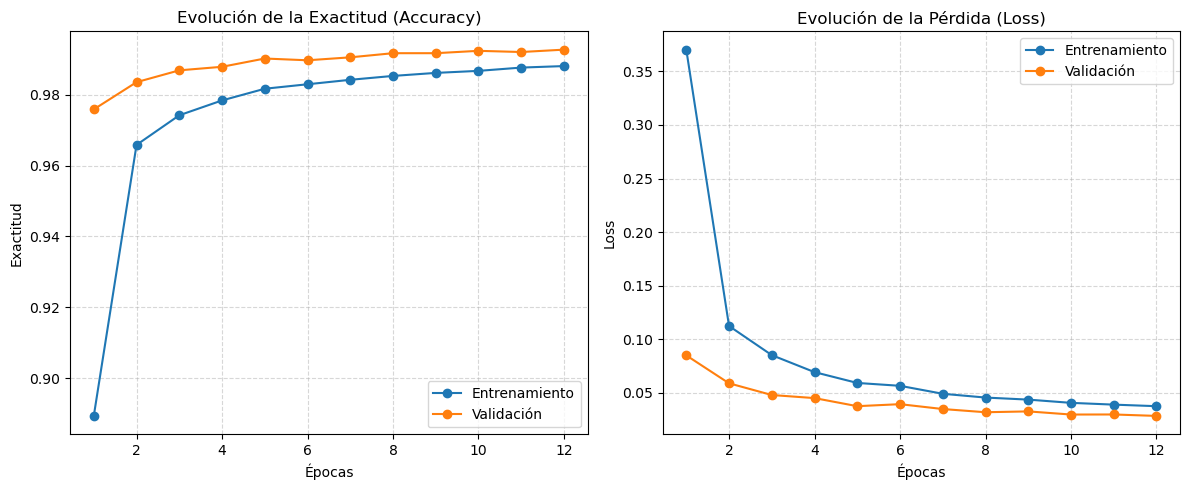

In [11]:
# Asumiendo que 'history' es la variable donde guardaste el entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# 1. Gráfica de Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento', marker='o')
plt.plot(epochs_range, val_acc, label='Validación', marker='o')
plt.title('Evolución de la Exactitud (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Gráfica de Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento', marker='o')
plt.plot(epochs_range, val_loss, label='Validación', marker='o')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Con esta representación visual reafirmamos lo mencionado en los datos anteriores y además nos permite observar mejor el comportamiento mediante la geometría de las curvas.

En el gráfico de accuracy, vemos una pendiente inicial muy pronunciada (aprendizaje rápido de características básicas) que se suaviza rápidamente formando la meseta o asíntota a partir de la época 5. Esto indica la convergencia del modelo. Se aprecia además cómo la línea de validación (naranja) se mantiene por encima de la de entrenamiento (azul), y esto se debe al efecto Dropout, demostrando que el modelo generaliza mejor ante datos nuevos que con los datos de entrenamiento ruidosos.

En el gráfico de pérdida, en situaciones de sobreajuste, esperaríamos ver que la línea de validación comenzara a subir en el lado derecho del gráfico, separándose de la línea de entrenamiento, formando una U. Sin embargo, observamos que ambas líneas descienden y se mantienen paralelas cerca del eje cero. Se observan además, las pequeñas oscilaciones finales en la línea de validación, confirmando la generalización robusta.

# Comparación de modelos y conclusiones

Tras comparar el los resultados de ambos modelos, podemos concluir que la CNN es el modelo superior para esta tarea de clasificación de imágenes, superando al RF tanto en métricas finales como en capacidad de generalización.

Primeramente, aunque el Random Forest estableció una línea base robusta con un accuracy del 97%, este no llega a mejorar un 1% más tras haberle añadido hasta 150 árboles más, pasando de un 97.04% con 100 árboles a un 97.11% con 250 árboles, mostrando un claro estancamiento y por tanto límite del modelo. Además, el reporte de clasificación del RF evidencia dificultades sutiles para distinguir clases morfológicamente más complejas como los dígitos 3, 8 y 9, donde el f1-score bajó a 0.96.
Sin embargo, la CNN demostró un gran rendimiento desde la primera época de entrenamiento. El modelo alcanzó una exactitud final en validación del 99.15%, superando el mejor resultado del modelo anterior ya en la primera época, donde obtuvo un 97.88%, demostrando la eficiencia de esta arquitectura para este tipo de datos.

Esta diferencia de rendimiento se debe a cómo cada modelo procesa la información visual, pues el RF al requerir un flattening de la imagen a un vector unidimensional, pierde la información espacial y estructural, tratando los píxeles como características independientes e ignorando las relaciones de vecindad que definen las formas y trazos. En cambio, la arquitectura convolucional preserva la estructura 2D de la imagen. Mediante el uso de filtros, la CNN es capaz de extraer jerarquías de características (bordes, curvas, bucles) y posee invarianza traslacional, lo que le permite reconocer el dígito independientemente de pequeñas variaciones en su posición o estilo de escritura.

Con esto, aunque el Random Forest es un modelo competente y rápido de entrenar, la CNN es la elección definitiva para este problema debido a su naturaleza con mayor eficacia para el análisis de imágenes.

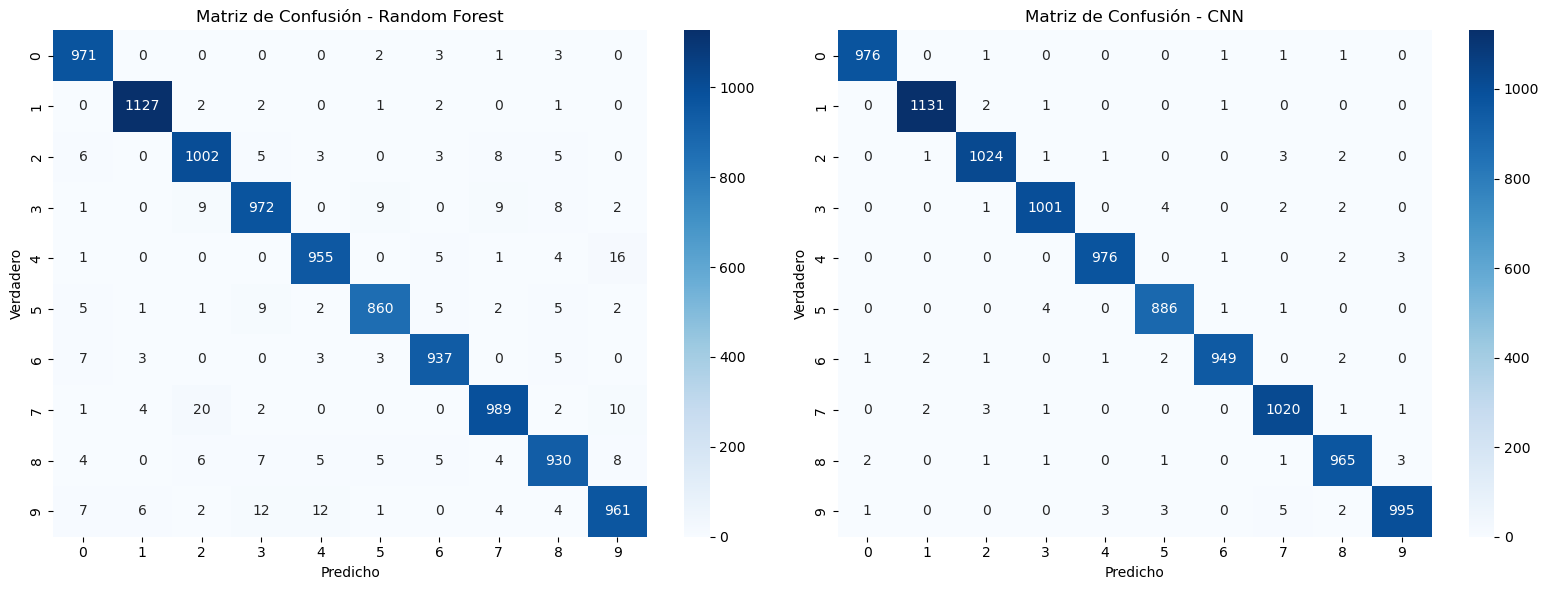

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Modificamos la función para recibir un argumento extra: 'ax'
def plot_confusion_matrix_on_ax(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    
    # En lugar de crear plt.figure, dibujamos sobre 'ax'
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    
    ax.set_title(title)
    ax.set_ylabel('Verdadero')
    ax.set_xlabel('Predicho')

# 2. Creamos la figura global con 2 subplots (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3. Llamamos a la función pasando el eje específico (axes[0] y axes[1])
# Para Random Forest (Izquierda)
plot_confusion_matrix_on_ax(y_test, y_pred_rf, "Matriz de Confusión - Random Forest", axes[0])

# Para CNN (Derecha)
plot_confusion_matrix_on_ax(y_test, y_pred_cnn, "Matriz de Confusión - CNN", axes[1])

# Ajustes finales para que no se solapen textos
plt.tight_layout()
plt.show()

El análisis de las matrices de confusión refuerza de manera visual las conclusiones anteriores. En el caso del Random Forest, aunque la diagonal principal concentra la mayoría de las predicciones correctas, se observan confusiones recurrentes (los valores fuera de la diagonal) entre dígitos con morfologías similares, como el 3 con el 5, el 7 con el 2 o el 9 con el 4. Estas confusiones indican que el modelo presenta mayores dificultades para capturar patrones estructurales complejos, especialmente cuando las diferencias entre clases dependen de la disposición espacial de los trazos. 

Por el contrario, la matriz de la CNN presenta una diagonal más marcada y limpia, con un número significativamente menor de errores. Las confusiones entre clases son más escasas y dispersas, lo que evidencia una mejor capacidad del modelo para discriminar entre dígitos visualmente similares. Este comportamiento confirma que la red convolucional ha aprendido representaciones internas más robustas y discriminativas, capaces de generalizar mejor ante variaciones en la escritura.

## Mejoras y aplicaciones prácticas

Aunque hayamos conseguido que la CNN tenga un gran rendimiento (99.15%), podríamos mejorarlo aún más. Una opción que nos podría ayudar sería la implementación de Data Augmentation (rotaciones, zooms y desplazamientos aleatorios en las imágenes de entrenamiento) para obligar a la red a generalizar mejor ante caligrafías inusuales y reducir el riesgo de overfitting. Además, también se podría realizar un mejor ajuste de hiperparámetros, pues debido a que son numerosos y el coste computacional es alto, no se ha empleado en este trabajo por haber podido tardar horas o incluso días para obtener un resultado. Con esto, se podrían añadir capas de regularización (Dropout o Batch Normalization) para estabilizar aún más la convergencia. Y para que la red pudiese aprender más y generalizar mejor, se podrían añadir muchas más muestras de distintas personas (sería interesante que el dataset fuese hecho por nosotros mismos con personas conocidas), o incluso entrenarlo para que empezara a aprender también letras. 

La utilidad de este modelo va más allá del ámbito académico. Una solución capaz de reconocer dígitos manuscritos con una fiabilidad superior al 99% es crítica para la automatización de procesos masivos. Ejemplos de aplicaciones inmediatas y relevantes podrían ser la logística y correos (lectura automática de códigos postales para clasificación de paquetería), el sector bancario (procesamiento de importes en cheques y formularios) y la digitalización de archivos históricos en hospitales o administraciones públicas, permitiendo transformar grandes volúmenes de registros en papel a bases de datos digitales estructuradas.

Este proyecto ha evidenciado la superioridad del Deep Learning frente al Machine Learning clásico para tareas de percepción visual. Mientras que el Random Forest estableció una línea base sólida y rápida, se topó con un límite técnico al no poder interpretar la relación espacial entre los píxeles. La CNN, por el contrario, demostró su capacidad para "entender" la estructura de la imagen (trazos y formas), logrando reducir la tasa de error drásticamente. Esto confirma que, para problemas de visión artificial, la complejidad computacional de las redes neuronales es una inversión necesaria que garantiza la precisión requerida en el mundo real.